# Time Processing — worked examples

The companion notebook to the [Time Processing
manual](../../docs/manuals/time-processing.md). Same three examples, same
demo files, same numbers — computed here in a few lines of
`spwb.processing` instead of clicked in the application.

The manual carries the explanations and the history; this notebook is
where you change a parameter and watch what happens. Nothing here imports
Qt, so it runs anywhere `pip install spwb[io]` runs.

### Three ways to use this, needing progressively more

1. **Read it.** GitHub renders this file with every graph and number
   already in place. Nothing to install, nothing to run.
2. **Run it as a script** — no Jupyter involved at all:
   `python examples/manuals/time_processing.py`
3. **Run it cell by cell** in VS Code or Jupyter, which is the point of
   it: change a trend type, a window length, a calibration factor.

For (3), VS Code will ask which kernel to use. **Choose the Python
interpreter you installed SPWB into** — the same one `pip install -e .`
was run with. There is no separate "spwb" environment unless you created
one yourself. If it is not offered in the list, run `pip install ipykernel`
into it and reopen the notebook.

| Section | Demo file | Shows |
|---|---|---|
| 1 | `01_TimeProcessing_Stats_known_values.h5` | Every Stats column against a textbook value |
| 2 | `03_TimeProcessing_Calibration_raw_volts.h5` | Sensitivity, calibration, normalisation |
| 3 | `02_TimeProcessing_TVmetrics_trends.h5` | Sliding-window trends and what limits them |

Every section ends with an `assert` on the numbers the manual quotes, so
running this notebook top to bottom is itself a check that the port still
behaves.

## Setup

The demo datasets are generated rather than committed — they are 21 MB,
and `spwb.demo` reproduces them exactly from a fixed seed. The cell below
creates them if they are missing, so there is nothing to download. The
application offers the same thing under **File > Create Demo Data ...**.

In [1]:
from pathlib import Path

import numpy as np

try:                                    # notebook: draw figures inline
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:                       # plain script: draw to a buffer
    import warnings

    import matplotlib
    matplotlib.use("Agg")
    # plt.show() is a no-op under Agg and says so once per figure; the
    # figures are still built, and the notebook build uses the inline
    # backend where they are captured.
    warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")
import matplotlib.pyplot as plt


def demo_folder() -> Path:
    """Where the demonstration datasets live.

    A git checkout keeps them in its own untracked ``.data/``. Anyone who
    installed the wheel has no checkout and gets them in a folder beside
    wherever they are working instead. Either way ``spwb.demo`` writes them
    on demand - the generator ships inside the package precisely so this
    notebook does not require a clone.
    """
    here = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()
    for folder in (here, *here.parents):
        if (folder / "pyproject.toml").is_file() and (folder / "src").is_dir():
            return folder / ".data"
    return Path.cwd() / "spwb-demo-data"


DATA = demo_folder()

if not any(DATA.glob("[0-9][0-9]_*.h5")):
    from spwb.demo import write_demo_data

    print(f"creating the demonstration datasets in {DATA} ...")
    write_demo_data(DATA)

print(f"datasets : {len(list(DATA.glob('*.h5')))} files in {DATA}")

datasets : 14 files in <your pySPWB checkout>\.data


In [2]:
from spwb.processing.dsp import conditioning as C
from spwb.processing.dsp import signal_statistics, time_varying_metric
from spwb.processing.dsp.metrics import TREND_TYPES
from spwb.processing.io import read_hdf5


def load(filename: str) -> dict:
    """Every signal in a demo file, keyed by name.

    Keyed rather than indexed on purpose: ``read_hdf5`` returns signals in
    the file's own alphabetical order, not the order they were written, so
    an index quietly selects the wrong trace.
    """
    return {s.name: s for s in read_hdf5(DATA / filename)}


def stats_table(signals, title=""):
    """The Stats tab, printed - same columns, same order."""
    if title:
        print(title)
    print(f"  {'Signal':26} {'Min':>8} {'Max':>8} {'Mean/DC':>9} {'RMS':>8} "
          f"{'Pk-Pk':>8} {'Crest':>7}")
    rows = {}
    for sig in signals:
        st = signal_statistics(sig)
        rows[sig.name] = st
        print(f"  {sig.name:26} {st.minimum:8.4f} {st.maximum:8.4f} "
              f"{st.mean:9.4f} {st.rms:8.4f} {st.peak_to_peak:8.4f} "
              f"{st.crest_factor:7.4f}")
    return rows


print("ready")

ready


## 1. Statistics you can check

**File:** `01_TimeProcessing_Stats_known_values.h5` — six signals whose
statistics are all textbook values, at 8192 Hz for 8 s.

Manual: [Worked example
1](../../docs/manuals/time-processing.md#worked-example-1--statistics-you-can-check).

`signal_statistics` is one call and returns one row of the Stats tab.

In [3]:
known = load("01_TimeProcessing_Stats_known_values.h5")
ORDER = ["DC 2.5 V", "Sine 1 Vpk", "Square 1 Vpk", "Gaussian noise sigma 1",
         "Uniform noise +/-1", "Sine 1 Vpk + 3 V offset"]

rows = stats_table([known[n] for n in ORDER])

print(f"\n  on paper:  sine RMS 1/sqrt(2) = {1 / np.sqrt(2):.6f}, "
      f"crest sqrt(2) = {np.sqrt(2):.6f}")
print(f"             uniform RMS 1/sqrt(3) = {1 / np.sqrt(3):.6f}")
print("             square wave: RMS equals peak, so crest is exactly 1 - "
      "the lowest\n             any signal can have")

  Signal                          Min      Max   Mean/DC      RMS    Pk-Pk   Crest
  DC 2.5 V                     2.5000   2.5000    2.5000   2.5000   0.0000  1.0000
  Sine 1 Vpk                  -1.0000   1.0000   -0.0000   0.7071   2.0000  1.4142
  Square 1 Vpk                -1.0000   1.0000    0.0000   1.0000   2.0000  1.0000
  Gaussian noise sigma 1      -4.8461   4.6784   -0.0081   1.0023   9.5245  4.8352
  Uniform noise +/-1          -1.0000   0.9999   -0.0009   0.5798   1.9998  1.7245
  Sine 1 Vpk + 3 V offset      2.0000   4.0000    3.0000   3.0822   2.0000  1.2978

  on paper:  sine RMS 1/sqrt(2) = 0.707107, crest sqrt(2) = 1.414214
             uniform RMS 1/sqrt(3) = 0.577350
             square wave: RMS equals peak, so crest is exactly 1 - the lowest
             any signal can have


**The one that surprises people.** The offset sine reads an RMS of 3.0822,
neither 3.0 nor 0.7071: a DC component and an AC component add in
quadrature. The Scale Signals tab removes the offset, and then the RMS is
the sine's own.

In [4]:
print(f"  sqrt(3^2 + 0.5) = {np.sqrt(9 + 0.5):.6f}   <- what the RMS reads\n")

offset_sine = known["Sine 1 Vpk + 3 V offset"]
removed = C.calibrate(offset_sine, factor=1.0, dc=-3.0)   # DC Offset = -3
before, after = signal_statistics(offset_sine), signal_statistics(removed)

print(f"  before : mean {before.mean:9.6f}   rms {before.rms:.6f}")
print(f"  after  : mean {after.mean:9.6f}   rms {after.rms:.6f}   "
      "<- the sine on its own")

  sqrt(3^2 + 0.5) = 3.082207   <- what the RMS reads

  before : mean  3.000000   rms 3.082207
  after  : mean -0.000000   rms 0.707107   <- the sine on its own


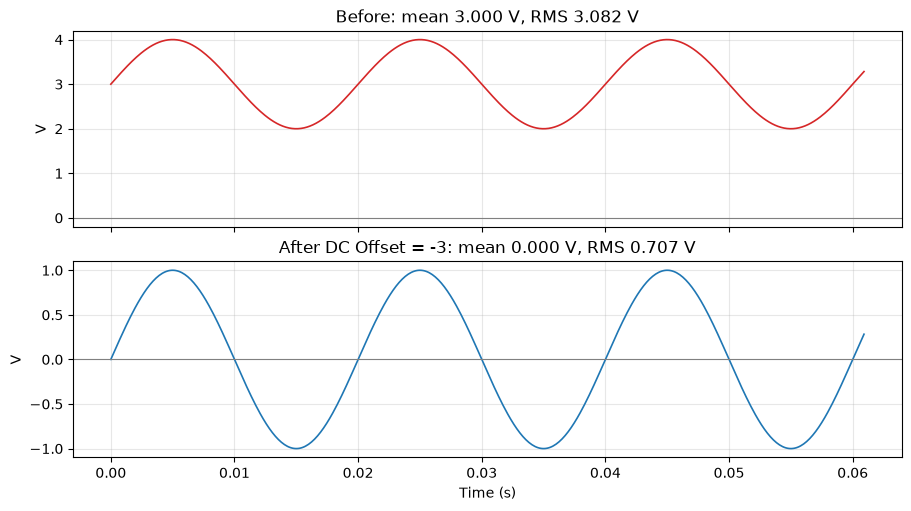

In [5]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(9, 5), sharex=True,
                                  constrained_layout=True)
window = slice(0, 500)
top.plot(offset_sine.t[window], offset_sine.y[window], lw=1.2, color="tab:red")
top.set(ylabel="V", title="Before: mean 3.000 V, RMS 3.082 V")
bottom.plot(removed.t[window], removed.y[window], lw=1.2, color="tab:blue")
bottom.set(xlabel="Time (s)", ylabel="V",
           title="After DC Offset = -3: mean 0.000 V, RMS 0.707 V")
for ax in (top, bottom):
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="grey", lw=0.8)
plt.show()

**Two readings that look wrong and are not.** The Gaussian signal's crest
factor is 4.8, because Gaussian noise has no bounded peak — the largest
sample depends on how long you recorded. And the uniform noise RMS is
0.5798 rather than 0.57735, because this is one finite sample of a random
process. Neither is a defect; both are why a crest factor is only
meaningful compared against the same measurement over time.

In [6]:
assert abs(rows["Sine 1 Vpk"].rms - 2 ** -0.5) < 1e-6
assert abs(rows["Sine 1 Vpk"].crest_factor - 2 ** 0.5) < 1e-4
assert abs(rows["Square 1 Vpk"].crest_factor - 1.0) < 1e-9
assert abs(rows["DC 2.5 V"].rms - 2.5) < 1e-9
assert abs(rows["Sine 1 Vpk + 3 V offset"].rms - np.sqrt(9.5)) < 1e-6
assert abs(after.rms - 2 ** -0.5) < 1e-6 and abs(after.mean) < 1e-9
print("section 1 OK - sine 0.7071/1.4142, square crest exactly 1, "
      "offset sine 3.0822 and 0.7071 once removed")

section 1 OK - sine 0.7071/1.4142, square crest exactly 1, offset sine 3.0822 and 0.7071 once removed


## 2. Calibration, or making volts mean something

**File:** `03_TimeProcessing_Calibration_raw_volts.h5` — an accelerometer
recording in raw volts from a 100 mV/g sensor, plus the same signal
already in g so you can check your work.

Manual: [Worked example
2](../../docs/manuals/time-processing.md#worked-example-2--calibration-or-making-volts-mean-something).

The **Calib Factor** is the reciprocal of the sensitivity: 100 mV/g is
0.1 V per g, so the factor is 10.

In [7]:
accel = load("03_TimeProcessing_Calibration_raw_volts.h5")
raw, true = accel["Accel raw"], accel["Accel true (for comparison)"]

calibrated = C.calibrate(raw, factor=10.0, dc=0.0,
                         name="Accel calibrated", unit="g")

rows = stats_table([raw, calibrated, true],
                   "the Stats tab, before and after:")
print(f"\n  units: raw {raw.y_unit!r} -> calibrated {calibrated.y_unit!r}, "
      f"reference {true.y_unit!r}")
print(f"  largest difference from the reference: "
      f"{float(np.max(np.abs(calibrated.y - true.y))):.3e}  "
      "<- floating point, not arithmetic")
print(f"  attributes recorded: "
      f"{ {k: v for k, v in calibrated.attributes.items() if k not in raw.attributes} }")

the Stats tab, before and after:
  Signal                          Min      Max   Mean/DC      RMS    Pk-Pk   Crest
  Accel raw                   -0.2000   0.2000    0.0000   0.1414   0.4000  1.4142
  Accel calibrated            -2.0000   2.0000    0.0000   1.4142   4.0000  1.4142
  Accel true (for comparison)  -2.0000   2.0000    0.0000   1.4142   4.0000  1.4142

  units: raw 'V' -> calibrated 'g', reference 'g'
  largest difference from the reference: 2.220e-16  <- floating point, not arithmetic
  attributes recorded: {'Channel Unit': 'g', 'Scale_Factor': 10.0, 'DC_Offset': 0.0}


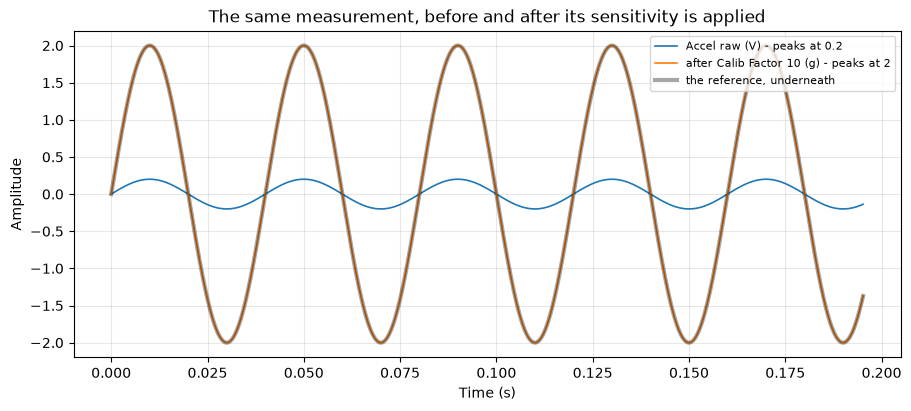

In [8]:
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
window = slice(0, 1600)
ax.plot(raw.t[window], raw.y[window], lw=1.2,
        label=f"Accel raw ({raw.y_unit}) - peaks at 0.2")
ax.plot(calibrated.t[window], calibrated.y[window], lw=1.2,
        label=f"after Calib Factor 10 ({calibrated.y_unit}) - peaks at 2")
ax.plot(true.t[window], true.y[window], lw=3, alpha=0.35, color="k",
        label="the reference, underneath")
ax.set(xlabel="Time (s)", ylabel="Amplitude",
       title="The same measurement, before and after its sensitivity is applied")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()

**The order matters:** the factor scales the raw signal and the offset is
added *afterwards*, in the calibrated unit. A 100 mV/g sensor with a
0.05 V bias is factor 10 and offset **-0.5 g**, not -0.05.

### Normalisation

For comparing shapes rather than levels. Watch what each option does to
the relative sizes.

In [9]:
mixed = [known["Sine 1 Vpk"], known["Square 1 Vpk"], known["DC 2.5 V"]]
print(f"  {'option':40} {'resulting peaks':26} preserves")
for option in C.NORMALIZATION_OPTIONS:
    out, max_all = C.normalize(mixed, option)
    peaks = [round(float(np.max(np.abs(s.y))), 4) for s in out]
    note = {"None": "everything (a no-op)",
            "To itself": "shape only - relative levels destroyed",
            }.get(option, "relative levels")
    print(f"  {option:40} {peaks!s:26} {note}")
print(f"\n  the largest peak in the set was {max_all:g}, which is what "
      "'to the max levels\n  of ALL the signals' divides everything by")

  option                                   resulting peaks            preserves
  None                                     [1.0, 1.0, 2.5]            everything (a no-op)
  To itself                                [1.0, 1.0, 1.0]            shape only - relative levels destroyed
  To the max levels of ALL the signals     [0.4, 0.4, 1.0]            relative levels

  the largest peak in the set was 2.5, which is what 'to the max levels
  of ALL the signals' divides everything by


In [10]:
cal_stats, true_stats = rows["Accel calibrated"], rows["Accel true (for comparison)"]
assert abs(cal_stats.maximum - 2.0) < 1e-9, cal_stats.maximum
assert abs(cal_stats.rms - true_stats.rms) < 1e-12
assert calibrated.y_unit == "g"
assert float(np.max(np.abs(calibrated.y - true.y))) < 1e-12
_itself, _ = C.normalize(mixed, "To itself")
assert all(abs(float(np.max(np.abs(s.y))) - 1.0) < 1e-9 for s in _itself)
print("section 2 OK - 0.2 V becomes 2.000000 g, matching the reference "
      "to 1e-12")

section 2 OK - 0.2 V becomes 2.000000 g, matching the reference to 1e-12


## 3. Trends, when one number is not enough

**File:** `02_TimeProcessing_TVmetrics_trends.h5` — three 10-second
signals shaped so the right trend is unmistakable.

Manual: [Worked example
3](../../docs/manuals/time-processing.md#worked-example-3--trends-when-one-number-is-not-enough).

A trend is a Signal in its own right, sampled at the step rather than at
the data rate — which is why the application can plot it over the data and
send it to an FFT window.

In [11]:
trends = load("02_TimeProcessing_TVmetrics_trends.h5")
bursts = trends["Four bursts 0.25 to 1.0"]

peak = time_varying_metric(bursts, "Absolute Peak",
                           step_ms=100.0, length_ms=1000.0, annotate=True)

print(f"  source : {bursts.n_samples:6d} points at {bursts.fs:.4f} Hz "
      f"over {bursts.n_samples / bursts.fs:.3f} s")
print(f"  trend  : {peak.n_samples:6d} points at {peak.fs:.4f} Hz "
      f"over {peak.n_samples / peak.fs:.3f} s   name={peak.name!r}")
print("\n  the staircase, one step per burst:")
for at in (0.5, 1.5, 3.5, 5.5, 7.5, 9.0):
    k = int(round(at / peak.dt))
    if k < peak.n_samples:
        print(f"    t = {at:4.1f} s -> {float(peak.y[k]):.4f}")

  source :  81920 points at 8192.0000 Hz over 10.000 s
  trend  :     91 points at 10.0024 Hz over 9.098 s   name='Four bursts 0.25 to 1.0 (TVM)'

  the staircase, one step per burst:
    t =  0.5 s -> 0.2500
    t =  1.5 s -> 0.2500
    t =  3.5 s -> 0.5000
    t =  5.5 s -> 0.7500
    t =  7.5 s -> 1.0000
    t =  9.0 s -> 0.0000


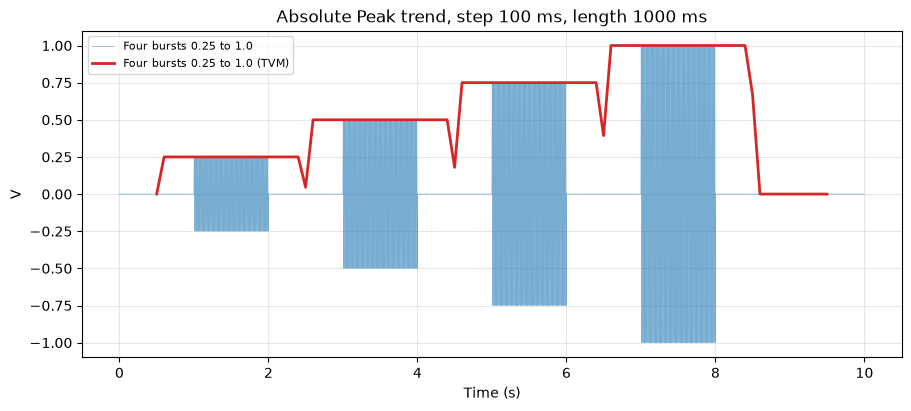

In [12]:
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(bursts.t, bursts.y, lw=0.5, alpha=0.6, label=bursts.name)
ax.plot(peak.t, peak.y, lw=2, color="tab:red", label=peak.name)
ax.set(xlabel="Time (s)", ylabel="V",
       title="Absolute Peak trend, step 100 ms, length 1000 ms")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="upper left")
plt.show()

### Three things about that trend which are not mistakes

**It is shorter than the signal** — each point needs a full window, so the
last one starts a second before the end. **The step is not exactly
100 ms** — it must be a whole number of samples. **The corners slope** —
a window straddling the start of a burst contains some of each.

In [13]:
n_step = round(0.100 * bursts.fs)
print(f"  requested step 100 ms -> {n_step} samples -> "
      f"{n_step / bursts.fs * 1000:.4f} ms actually")
print(f"  trend covers {peak.n_samples / peak.fs:.3f} s of a "
      f"{bursts.n_samples / bursts.fs:g} s record\n")

print(f"  {'step (ms)':>10} {'length (ms)':>12} {'points':>7} {'covers (s)':>11}")
for step, length in ((100, 1000), (100, 200), (500, 1000), (50, 500)):
    tr = time_varying_metric(bursts, "Absolute Peak",
                             step_ms=step, length_ms=length)
    print(f"  {step:10g} {length:12g} {tr.n_samples:7d} "
          f"{tr.n_samples / tr.fs:11.3f}")
print("\n  shorten Length to sharpen the corners, at the cost of a noisier\n"
      "  trend - the same trade the Time-Frequency window makes")

  requested step 100 ms -> 819 samples -> 99.9756 ms actually
  trend covers 9.098 s of a 10 s record

   step (ms)  length (ms)  points  covers (s)
         100         1000      91       9.098
         100          200      99       9.898
         500         1000      19       9.500
          50          500     190       9.509

  shorten Length to sharpen the corners, at the cost of a noisier
  trend - the same trade the Time-Frequency window makes


### What each trend type computes

The steady 0.5 Vpk reference is flat under every trend, which makes it the
right signal for reading the definitions off.

In [14]:
steady = trends["Steady 0.5 Vpk reference"]
TEXTBOOK = {"RMS": 0.5 / np.sqrt(2), "Absolute Peak": 0.5, "Range": 1.0,
            "Skewness": 0.0, "Kurtosis": 1.5}

print(f"  {'trend':20} {'value':>11} {'spread':>10}   textbook for a sine")
flat = {}
for trend in TREND_TYPES:
    tr = time_varying_metric(steady, trend, step_ms=100.0, length_ms=1000.0)
    value = float(np.median(tr.y))
    flat[trend] = value
    want = TEXTBOOK.get(trend)
    print(f"  {trend:20} {value:11.6f} {float(tr.y.max() - tr.y.min()):10.1e}"
          f"   {'' if want is None else f'{want:.6f}'}")

bessel = np.sqrt(8192 / 8191)
print(f"\n  Standard Deviation reads above RMS - 0.353575 against 0.353553 - "
      f"because\n  SPWB follows NI in dividing by N-1. "
      f"0.353553 x sqrt(8192/8191) = {0.35355339 * bessel:.6f}")

  trend                      value     spread   textbook for a sine
  RMS                     0.353553    2.8e-16   0.353553
  Absolute Peak           0.500000    0.0e+00   0.500000
  Range                   1.000000    0.0e+00   1.000000
  Standard Deviation      0.353575    3.3e-16   
  Variance                0.125015    2.2e-16   
  Skewness               -0.000000    4.8e-15   0.000000
  Kurtosis                1.499634    3.3e-15   1.500000

  Standard Deviation reads above RMS - 0.353575 against 0.353553 - because
  SPWB follows NI in dividing by N-1. 0.353553 x sqrt(8192/8191) = 0.353575


**And this is where the shape statistics earn their place.** On Gaussian
noise they land on the textbook values for a normal distribution — and the
reason anyone watches kurtosis on a machine is that a developing bearing
fault pushes it above 3 long before the RMS moves.

In [15]:
gaussian = known["Gaussian noise sigma 1"]
print(f"  {'trend':20} {'median':>10}   textbook for Gaussian noise")
shape = {}
for trend, want in (("Standard Deviation", 1.0), ("Variance", 1.0),
                    ("Skewness", 0.0), ("Kurtosis", 3.0)):
    tr = time_varying_metric(gaussian, trend, step_ms=100.0, length_ms=1000.0)
    shape[trend] = float(np.median(tr.y))
    print(f"  {trend:20} {shape[trend]:10.5f}   {want:.1f}")

  trend                    median   textbook for Gaussian noise
  Standard Deviation      1.00468   1.0
  Variance                1.00938   1.0
  Skewness               -0.00534   0.0
  Kurtosis                2.96297   3.0


In [16]:
for at, want in ((1.5, 0.25), (3.5, 0.50), (5.5, 0.75), (7.5, 1.00)):
    got = float(peak.y[int(round(at / peak.dt))])
    assert abs(got - want) < 1e-6, f"t={at}: {got} != {want}"
assert peak.n_samples == 91
assert abs(flat["Kurtosis"] - 1.5) < 0.001, flat["Kurtosis"]
assert abs(flat["RMS"] - 0.5 / np.sqrt(2)) < 1e-9
assert abs(flat["Standard Deviation"] - flat["RMS"] * bessel) < 1e-9
assert abs(shape["Kurtosis"] - 3.0) < 0.1, shape["Kurtosis"]
assert abs(shape["Standard Deviation"] - 1.0) < 0.02
print("section 3 OK - staircase 0.25/0.50/0.75/1.00, sine kurtosis 1.4996, "
      "Gaussian 2.963")

section 3 OK - staircase 0.25/0.50/0.75/1.00, sine kurtosis 1.4996, Gaussian 2.963


## Where to go next

* The [Time Processing manual](../../docs/manuals/time-processing.md) —
  the same three examples driven through the application, plus the history
  of where all of this came from and a reference table for every control.
* The [FFT Analysis manual](../../docs/manuals/fft-analysis.md) and its
  [notebook](fft_analysis.py) — where these signals go next.
* `python tools/verify_demo_data.py` — the assertions that keep the demo
  datasets honest.

To use your own data, replace the `load(...)` calls with
`read_tdms("run.tdms")`, `read_wave("take1.wav")` or
`read_hdf5("measurement.h5")`. Everything downstream is unchanged.

---

## Support This Work

If anything here was useful to you, please consider contributing.
SPWB is free and open source, and always will be — donations are
what let Charette AI Group keep maintaining it and open-sourcing
its other tools.

<p align="center">
  <a href="https://www.paypal.com/donate/?hosted_button_id=FEM4WLD7LHY36">
      <img src="https://www.paypalobjects.com/en_US/i/btn/btn_donateCC_LG.gif" alt="Donate with PayPal">
  </a>
</p>